In [1]:
%matplotlib inline
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np
# use seaborn plotting defaults
import seaborn as sns; sns.set_theme()
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [2]:
#Cargar datos
path = os.path.join('df_final.csv')
df = pd.read_csv(path)

In [3]:
# Seleccionar solo columnas numéricas
df_numericas = df.select_dtypes(include = np.number)
print("Variables numéricas:", df_numericas.shape)

#ESCALADO
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numericas)

Variables numéricas: (53747, 17)


In [4]:
# 7. PCA (REDUCE EL RUIDO)
# Mantiene el 90% de la varianza
# -------------------------------------------------------------
from sklearn.decomposition import PCA
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print("Dimensiones tras PCA:", X_pca.shape)

Dimensiones tras PCA: (53747, 11)


In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

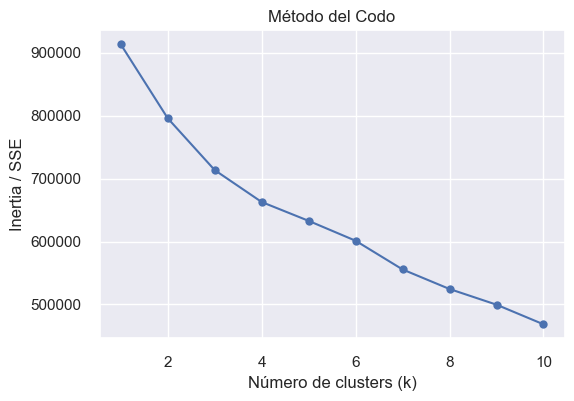

In [12]:
inertias = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inertia / SSE")
plt.title("Método del Codo")
plt.show()

In [6]:
k = 4   # cambia por el valor que te indique el codo
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

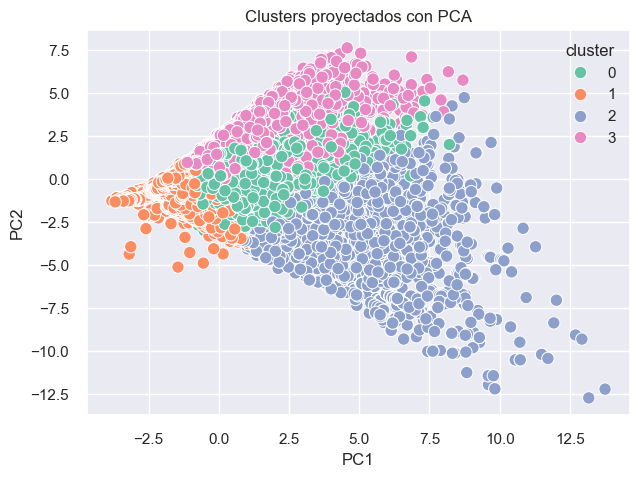

In [7]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=df['cluster'],
    palette='Set2',
    s=80
)
plt.title("Clusters proyectados con PCA")
plt.show()

In [ ]:
model = KMeans()
#create a KElbowVisualizer with the previously defined parameters
visualizer = KElbowVisualizer(model, k = range(2,15), timings = True)
visualizer.fit(X_pca)        # Fit data to visualizer
visualizer.show()        # Finalize and render figure
best_k = visualizer.elbow_value_
print("K óptimo encontrado:", best_k)

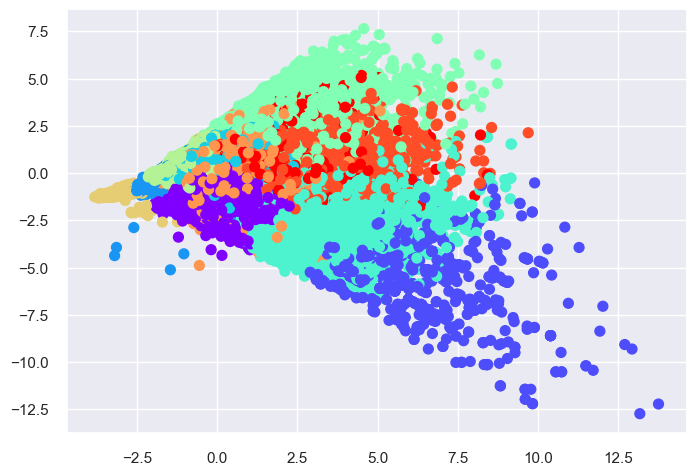

In [9]:
# create a KMeans model with the optimal n_clusters calculated in the previous part and fit it to the data X
# visualize the resulting clusters
n_clusters = 11
modelo_bueno =KMeans(n_clusters)
modelo_bueno.fit(X_pca) #Entrena el modelo K-means con los datos X
y_kmeans = modelo_bueno.predict(X_pca)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, s=50, cmap='rainbow')

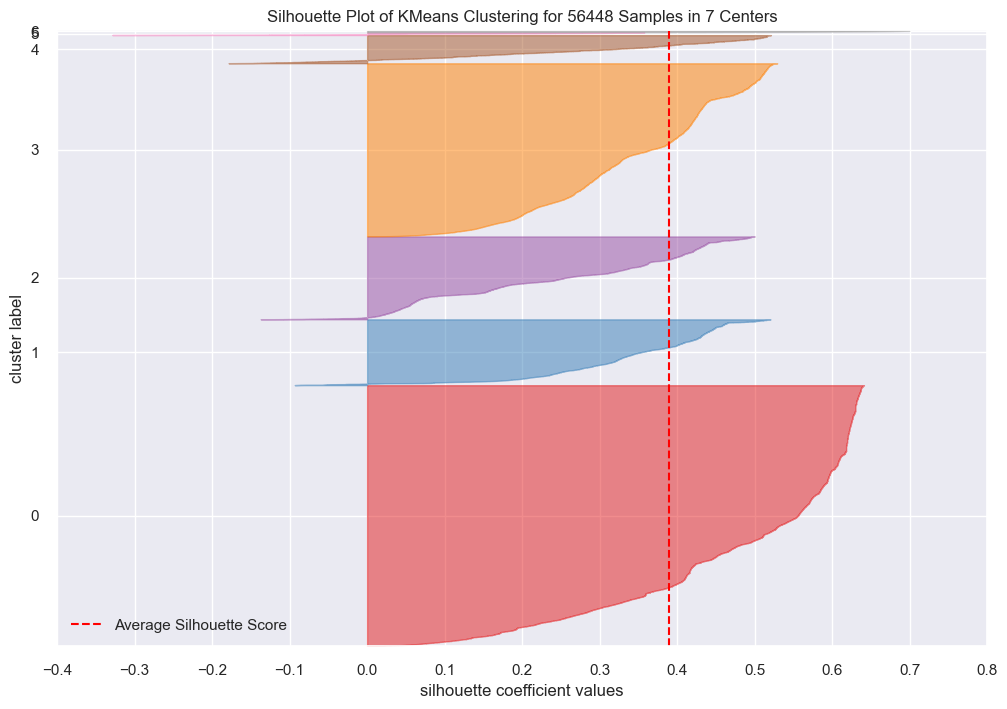

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 56448 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [9]:
from yellowbrick.cluster import SilhouetteVisualizer

# create a SilhouetteVisualizer from the K-Means model
fig, ax = plt.subplots(figsize=(12, 8))
sil_visualizer = SilhouetteVisualizer(modelo_bueno, sort = True)
sil_visualizer.fit(X_pca)
sil_visualizer.show()

# fit() the visualizer to the data and call the show() function